# RF SQUID chain amplifiers with fabrication disorder using parameters from paper

In this notebook we investigate RF SQUID chain amplifiers with fabrication disorder. 

We generate 10x realizations of disorder on critical currents of the Josephson junctions. Other parameters are treated as clean.

We sweep L and C in order to find the sweet spot for fabrication.

In [1]:
import sys
sys.path.insert(0, '../')

In [2]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.integrate import solve_ivp

from joblib import Parallel, delayed
from tqdm import tqdm
from dataclasses import dataclass

from typing import Callable

from circuit_network import CircuitNetwork
from circuit_network import CPR
from circuit_network import PHI_0_RED

from josephson_gain import find_resonant_freq
from josephson_gain import find_pump_amplitude

import pandas as pd
import seaborn as sns
from ipywidgets import interact

from collections import Counter

from pae_explorer import make_pae_explorer
from sweep_explorer import make_sweep_explorer
from flux_explorer import plot_pae_vs_flux, make_flux_explorer

from functools import partial
from joblib import Parallel, delayed
from rf_squid_chain import (
    make_realizations, make_job, run_job, make_rf_squid_chain, _broadcast_fluxes
)

# pre-run no disorder

In [3]:
# NICK non-degenerate

omega_p = (2.*np.pi)*12.0E9       # This sets the pump frequency in Hz
nc_Pump = 249                   # Time span in number of pump cycles that we will use in the FFT

nc_Signal = 125                 # Number of signal cycles that will fit into the time period that we use in the FFT 
phi_p = 0                       # phase offset between signal and pump, only needed for degenerate amplifiers 

print(f"Signal frequency={(nc_Signal/nc_Pump)*(omega_p/(2.0*np.pi))*1E-9} GHz")
warmupTime = 10e-9              # Time span for transients to die down before we start collecting data for FFT 

Signal frequency=6.024096385542169 GHz


In [5]:
C1 = 0.5E-12
kappa = 2.36e9*2*np.pi    # Damping rate, set to make sure that the quality factor is 10 at signal frequency *)
L1=(18.1E-12)*np.ones(10)
L1p=(0.001E-12)*np.ones(10)
L2p=0.001E-12
Ic=(18.1e-6)*np.ones(10)
phi_ext=1.*np.ones(10)

mean = {
    'L1':       L1,
    'L1p':      L1p,
    'L2p':      L2p,
    'Ic':       Ic,
    'phi_ext0': phi_ext,
    'kappa':    kappa,
    'C1':       C1,
}

sigma = {
    # missing keys → zero disorder
}

realizations = make_realizations(mean, sigma, n_realizations=1, seed=42)

cm=1.0
jobs = []

#for im in np.arange(0.23,1.001,0.05):
for im in [0.05,0.1,0.15,0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    for lm in [0.9, 0.92, 0.94, 0.96, 0.98, 1.0]:
        for pm in np.arange(2.4, 3.142, 0.002):
            for di in range(len(realizations)):
                jobs.append(
                    make_job(base=realizations[di],
                        disorder_index=di,
                        im=im,
                        cm=cm,
                        lm=lm,
                        pm=pm)
                )
print(f'Number of jobs={len(jobs)}')

Number of jobs=26712


In [6]:
run = partial(run_job,
              warmup_time = warmupTime,
              omega_p     = omega_p,
              nc_pump     = nc_Pump,
              phi_p       = phi_p,
              nc_signal   = nc_Signal)

# --- Run in parallel with a progress bar ---
results = []
with tqdm(total=len(jobs), desc="Sweeping jobs") as pbar:
    for r in Parallel(n_jobs=-1, return_as="generator")(
        delayed(run)(job) for job in jobs
    ):
        results.append(r)
        pbar.update(1)

Sweeping jobs: 100%|██████████████████████████████████████████████████████████████| 26712/26712 [32:08<00:00, 13.85it/s]


In [27]:
Counter(r['status'] for r in results)

Counter({'omega_out_of_range': 13132,
         'ok': 5606,
         'no_pump_bias_found': 1295,
         'fail_omega': 1})

In [28]:
realizations[0]

BaseRealization(baseL1=array([1.81e-11, 1.81e-11, 1.81e-11, 1.81e-11, 1.81e-11, 1.81e-11,
       1.81e-11, 1.81e-11, 1.81e-11, 1.81e-11]), baseL1p=array([1.e-15, 1.e-15, 1.e-15, 1.e-15, 1.e-15, 1.e-15, 1.e-15, 1.e-15,
       1.e-15, 1.e-15]), baseL2p=1e-15, baseIc=array([1.81e-05, 1.81e-05, 1.81e-05, 1.81e-05, 1.81e-05, 1.81e-05,
       1.81e-05, 1.81e-05, 1.81e-05, 1.81e-05]), basephi_ext0=array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]), basekappa=14828317324.943823, baseC1=5e-13)

In [29]:
meanIc=np.mean(realizations[0].baseIc)
meanL1=np.mean(realizations[0].baseL1)
meanL1p=np.mean(realizations[0].baseL1p)

df = pd.DataFrame([
    {
        'di':  r['job'].disorder_index,
        'im':  r['job'].im,
        'cm':  r['job'].cm,
        'lm':  r['job'].lm,
        'pm':  r['job'].pm,
        'PAE': r['result']['pae'] if r['result'] is not None else np.nan,
        'designIc':  r['job'].im*meanIc,
        'designL1':  (r['job'].lm/r['job'].im)*meanL1,
        'designBetaPrime': r['job'].lm*meanIc*meanL1/PHI_0_RED,
        'sweep_pump' : np.array(r['result']['sweep_pump']) if r['result'] is not None else np.nan,
        'sweep_signal' : np.array(r['result']['sweep_signal']) if r['result'] is not None else np.nan,
    }
    for r in results
])

In [30]:
make_sweep_explorer(df, use_design_params=True)

In [107]:
sns.set_theme()
sns.set(font_scale=1.5)
sns.set_style("ticks")
make_flux_explorer(df, use_design_params=True)

In [32]:
make_pae_explorer(df, use_design_params=True)

In [137]:
import importlib, flux_explorer
importlib.reload(flux_explorer)
from flux_explorer import plot_pae_vs_flux, make_flux_explorer

make_flux_explorer(df, use_design_params=True, xlim=[2.363,3.18], ylim=[0, 0.11])

# Single line — three filters, no series
#plot_pae_vs_flux(df, fix={'di': 0, 'im': 1.0, 'lm': 0.94})

In [33]:
ds=df[(df['im']==1) & (df['lm']==1.0)].iloc[69].copy()
ds

di                        0
im                      1.0
cm                      1.0
lm                      1.0
pm                    2.538
PAE                     0.0
designIc           0.000018
designL1                0.0
designBetaPrime    0.995454
sweep_pump               []
sweep_signal             []
Name: 19732, dtype: object

In [34]:
plt.plot(20*np.log10(ds['sweep_signal'][:,0]),10*np.log10(ds['sweep_signal'][:,1]))
plt.plot([-80,-10],[19,19], color='gray', linewidth=0.5)
plt.plot([-80,-10],[20,20], color='gray', linewidth=0.5)
plt.plot([-80,-10],[21,21], color='gray', linewidth=0.5)
plt.xlabel('Signal power [AU, dB]')
plt.ylabel('Power gain [dB]')
plt.show()

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

Text(0, 0.5, 'PAE')

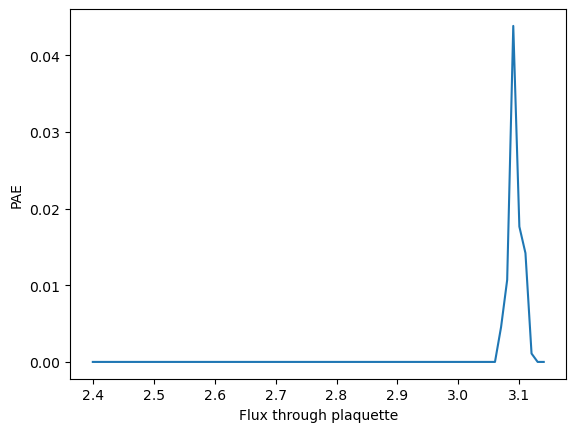

In [14]:
plt.plot(df[(df['im']==1) & (df['lm']==1)]['pm'], df[(df['im']==1) & (df['lm']==1)]['PAE'])
plt.xlabel('Flux through plaquette')
plt.ylabel('PAE')

In [15]:
max(df[(df['im']==1) & (df['lm']==1)]['PAE'])

0.04380895556839432

<Axes: title={'center': 'Circuit network — 22 nodes, 31 branches'}>

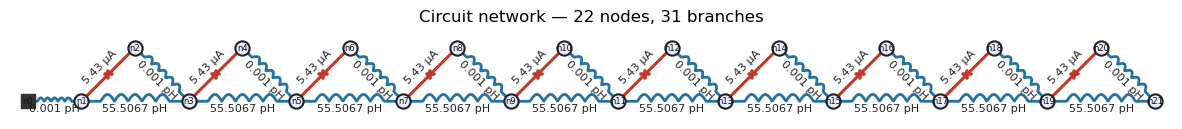

In [35]:
job=jobs[2964]
cn=make_rf_squid_chain(
    job.L1,
    job.L1p,
    job.L2p,
    job.Ic,
    fluxes=job.phi_ext0)

cn.draw(show_values=True, figsize=[15,5])

In [17]:
cpr_data = CPR(make_rf_squid_chain, {
        "L1":     job.L1,
        "L1p":    job.L1p,
        "L2p":    job.L2p,
        "Ic":     job.Ic,
        "fluxes": _broadcast_fluxes(job.phi_ext0, len(job.L1)),
    }, verbose=True)
cpr_data
# if cpr_data["fail"]:
#     return {"job": job, "result": None, "status": "cpr_failed"}

{'phi': [],
 'current': [],
 'fail': False,
 'cpr': <scipy.interpolate._cubic.CubicSpline at 0x159514550>,
 'cn': CircuitNetwork(nodes=22, branches=31),
 'phis': array([-200.  , -199.75, -199.5 , ...,  199.5 ,  199.75,  200.  ],
       shape=(1601,)),
 'currents': array([-0.0002886 , -0.00028825, -0.00028791, ...,  0.00029243,
         0.00029254,  0.00029267], shape=(1601,))}

In [18]:
injection_currents_up=cpr_data['currents']

In [19]:
if not np.all(np.diff(injection_currents_up) > 0):
    print('fail')

Text(0, 0.5, 'current [amp]')

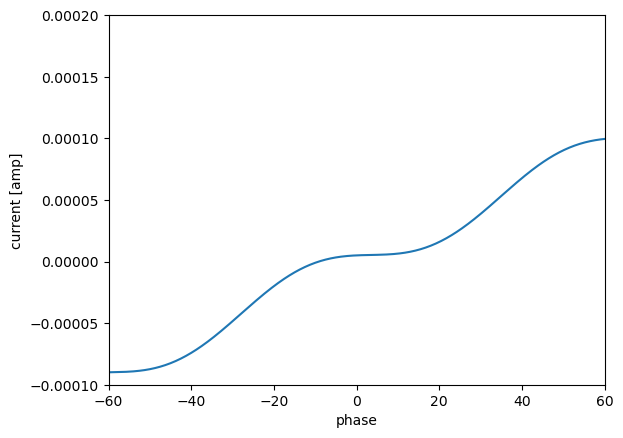

In [20]:
plt.plot(cpr_data['phis'],cpr_data['currents'])
plt.xlim(-60,60)
plt.ylim(-0.0001,0.0002)
plt.xlabel('phase')
plt.ylabel('current [amp]')

In [40]:
df_select=df[df['PAE']>0.02].copy()
print(f'Total number points: {len(df)}')
print(f'Number points with PAE>0.02: {len(df_select)}')

Total number points: 20034
Number points with PAE>0.02: 1202


In [41]:
df['designIc'].unique()

array([3.620e-06, 5.430e-06, 7.240e-06, 9.050e-06, 1.086e-05, 1.267e-05,
       1.448e-05, 1.629e-05, 1.810e-05])

In [102]:
import importlib, sweep_explorer
importlib.reload(sweep_explorer)
from sweep_explorer import make_sweep_explorer

In [125]:
sns.set_theme()
sns.set(font_scale=2.)
sns.set_style("ticks")
make_sweep_explorer(df_select, use_design_params=True, palette='viridis')

In [124]:
upm=set(np.sort(df['pm'].unique())[::10])
df1=df[df['pm'].isin(upm) & (df['im']==0.3) & (df['lm']==0.98)].copy()
make_sweep_explorer(df1, use_design_params=True, palette='viridis')

In [ ]:
upm=np.sort(df['pm'].unique())

sns.set_theme()
sns.set(font_scale=2.)
sns.set_style("ticks")
make_sweep_explorer(df, use_design_params=True, palette='viridis')

In [106]:
print(f'unique im={df_select['im'].unique()}')
print(f'unique lm={df_select['lm'].unique()}')
print(f'unique pm={df_select['pm'].unique()}')
#pmu=np.sort(df_select['pm'].unique())

unique im=[0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
unique lm=[0.9  0.92 0.94 0.96 0.98 1.  ]
unique pm=[2.556 2.558 2.56  2.562 2.564 2.566 2.568 2.57  2.572 2.574 2.576 2.578
 2.58  2.582 2.584 2.586 2.588 2.59  2.592 2.594 2.596 2.598 2.6   2.602
 2.604 2.606 2.608 2.61  2.612 2.614 2.616 2.618 2.62  2.622 2.624 2.626
 2.628 2.63  2.632 2.634 2.636 2.638 2.64  2.642 2.644 2.646 2.648 2.65
 2.652 2.654 2.656 2.658 2.66  2.662 2.664 2.666 2.668 2.67  2.672 2.674
 2.676 2.678 2.68  2.682 2.504 2.506 2.508 2.51  2.512 2.514 2.516 2.518
 2.52  2.522 2.524 2.526 2.528 2.53  2.532 2.534 2.536 2.538 2.54  2.542
 2.544 2.546 2.548 2.55  2.552 2.554 2.684 2.686 2.688 2.69  2.692 2.694
 2.696 2.698 2.46  2.462 2.464 2.466 2.468 2.47  2.472 2.474 2.476 2.478
 2.48  2.482 2.484 2.486 2.488 2.49  2.492 2.494 2.496 2.498 2.5   2.502
 2.7   2.702 2.704 2.706 2.708 2.71  2.42  2.422 2.424 2.426 2.428 2.43
 2.432 2.434 2.436 2.438 2.44  2.442 2.444 2.446 2.448 2.45  2.452 2.454
 2.456 2.458 2.712 2.714 2

In [88]:
q=190
print(pmu[q])
df_select[df_select['pm']==pmu[q]]

2.7939999999999565


,di,im,cm,lm,pm,PAE,designIc,designL1,designBetaPrime,sweep_pump,sweep_signal
3536,0,0.3,1.0,0.96,2.794,0.029459,0.000005,5.792000e-11,0.955636,"[[1.0, 1.007162011473972], [1.0222644691132137...","[[0.0001, 99.9996049481304], [0.00010729163381..."
3907,0,0.3,1.0,0.98,2.794,0.066771,0.000005,5.912667e-11,0.975545,"[[1.0, 1.007039913800773], [1.0222644691132137...","[[0.0001, 99.99997974922266], [0.0001072781705..."
4278,0,0.3,1.0,1.00,2.794,0.029830,0.000005,6.033333e-11,0.995454,"[[1.0, 1.0068757218679238], [1.022264469113213...","[[0.0001, 99.99992071888076], [0.0001072682238..."


In [104]:
sns.set_theme()
sns.set(font_scale=2.)
sns.set_style("ticks")
make_sweep_explorer(df_select[df_select['pm']==pmu[q]], use_design_params=True)

# Run with disorder

In [44]:
sigma = {
    'Ic': 0.05*Ic
    # missing keys → zero disorder
}

realizations = make_realizations(mean, sigma, n_realizations=50, seed=42)

jobs_disorder = []

for idx, row in df_select.iterrows():
    for di in range(len(realizations)):
        jobs_disorder.append(
                    make_job(base=realizations[di],
                        disorder_index=di,
                        im=row['im'],
                        cm = row['cm'],            
                        lm = row['lm'], 
                        pm = row['pm'], )
                )
print(f'Number of jobs={len(jobs_disorder)}')

Number of jobs=60100


In [45]:
run = partial(run_job,
              warmup_time = warmupTime,
              omega_p     = omega_p,
              nc_pump     = nc_Pump,
              phi_p       = phi_p,
              nc_signal   = nc_Signal)

# --- Run in parallel with a progress bar ---
results_disorder = []
with tqdm(total=len(jobs_disorder), desc="Sweeping jobs") as pbar:
    for r in Parallel(n_jobs=-1, return_as="generator")(
        delayed(run)(job) for job in jobs_disorder
    ):
        results_disorder.append(r)
        pbar.update(1)

Sweeping jobs: 100%|████████████████████████████████████████████████████████████| 60100/60100 [1:59:23<00:00,  8.39it/s]


In [46]:
Counter(r['status'] for r in results_disorder)

Counter({'cpr_failed': 47246, 'ok': 12854})

In [47]:
df_disorder = pd.DataFrame([
    {
        'di':  r['job'].disorder_index,
        'im':  r['job'].im,
        'cm':  r['job'].cm,
        'lm':  r['job'].lm,
        'pm':  r['job'].pm,
        'PAE': r['result']['pae'] if r['result'] is not None else np.nan,
        'designIc':  r['job'].im*meanIc,
        'designL1':  (r['job'].lm/r['job'].im)*meanL1,
        'designBetaPrime': r['job'].lm*meanIc*meanL1/PHI_0_RED,
        'sweep_pump' : np.array(r['result']['sweep_pump']) if r['result'] is not None else np.nan,
        'sweep_signal' : np.array(r['result']['sweep_signal']) if r['result'] is not None else np.nan,
    }
    for r in results_disorder
])

In [48]:
#[0.23, 0.25, 0.3, 0.4, 0.5, 0.7, 0.9, 1.0]
#[0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]
df_sel=df_disorder[np.isclose(df_disorder['im'],0.2) & np.isclose(df_disorder['lm'],0.94)]

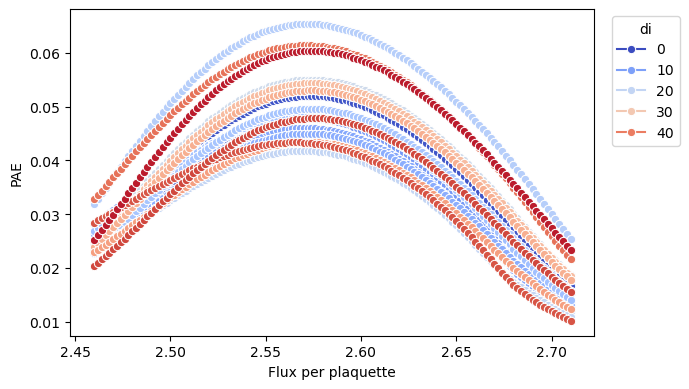

In [49]:
import seaborn as sns

plt.figure(figsize=(7, 4))
ax = sns.lineplot(data=df_sel, x='pm', y='PAE', hue=df_sel['di'], marker='o', errorbar=None,
             palette='coolwarm')
ax.set_xlabel('Flux per plaquette')
ax.set_ylabel('PAE')
ax.legend(title='di', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [127]:
sns.set_theme()
#sns.set(font_scale=2.)
sns.set_style("ticks")
make_pae_explorer(df_disorder, use_design_params=True)

In [51]:
make_sweep_explorer(df_disorder)

In [132]:
import importlib, flux_explorer
importlib.reload(flux_explorer)
from flux_explorer import plot_pae_vs_flux, make_flux_explorer

make_flux_explorer(df_disorder, use_design_params=True, xlim=[2.55,2.69], ylim=[0, 0.08])

# Single line — three filters, no series
#plot_pae_vs_flux(df, fix={'di': 0, 'im': 1.0, 'lm': 0.94})

In [229]:
len([g for g in df_disorder[(df_disorder['designIc']==3.620e-06) & 
    (np.abs(df_disorder['designBetaPrime']-0.9555)<0.001)].groupby('pm')])

150